In [34]:
# !pip install ucimlrepo

In [35]:
import numpy as np
import pandas as pd
import seaborn as sns


from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.mixture import GaussianMixture
from sklearn.metrics import mean_absolute_error
from nltk.cluster.kmeans import KMeansClusterer
from nltk.cluster.util import euclidean_distance
from sklearn.impute import KNNImputer

import matplotlib.pyplot as plt

# Exploring the SUPPORT2 Dataset

In [36]:
# --------------------------- Explore dataset ------------------------------
# copied from ucimlrepo web
from ucimlrepo import fetch_ucirepo

# fetch dataset
support2 = fetch_ucirepo(id=880)

# data (as pandas dataframes)
features = support2.data.features
targets = support2.data.targets

# # metadata
# print(support2.metadata)

# # variable information
support2.variables # aka list of all features/cols in dataset w/ descriptions of what each means 

,name,role,type,demographic,description,units,missing_values
0,id,ID,Integer,NaN,NaN,NaN,no
1,age,Feature,Continuous,Age,Age of the patients in years,years,no
2,death,Target,Continuous,NaN,Death at any time up to National Death Index (...,NaN,no
3,sex,Feature,Categorical,Sex,Gender of the patient. Listed values are {male...,NaN,no
4,hospdead,Target,Binary,NaN,Death in hospital,NaN,no
5,slos,Other,Continuous,NaN,Days from Study Entry to Discharge,NaN,no
6,d.time,Other,Continuous,NaN,Days of follow-up,NaN,no
7,dzgroup,Feature,Categorical,NaN,The patient's disease sub category amogst ARF/...,NaN,no
8,dzclass,Feature,Categorical,NaN,"The patient's disease category amongst ""ARF/MO...",NaN,no
9,num.co,Feature,Continuous,NaN,The number of simultaneous diseases (or comorb...,NaN,no


In [37]:
print(f"Number of features: {len(features.columns)}") 
print(f"Number of targets: {len(targets.columns)} -> {', '.join(targets.columns)}") 

Number of features: 42
Number of targets: 3 -> death, hospdead, sfdm2


In [38]:
# join together as 1 df for EDA 
df = features.join(targets)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9105 entries, 0 to 9104
Data columns (total 45 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       9105 non-null   float64
 1   sex       9105 non-null   str    
 2   dzgroup   9105 non-null   str    
 3   dzclass   9105 non-null   str    
 4   num.co    9105 non-null   int64  
 5   edu       7471 non-null   float64
 6   income    6123 non-null   str    
 7   scoma     9104 non-null   float64
 8   charges   8933 non-null   float64
 9   totcst    8217 non-null   float64
 10  totmcst   5630 non-null   float64
 11  avtisst   9023 non-null   float64
 12  race      9063 non-null   str    
 13  sps       9104 non-null   float64
 14  aps       9104 non-null   float64
 15  surv2m    9104 non-null   float64
 16  surv6m    9104 non-null   float64
 17  hday      9105 non-null   int64  
 18  diabetes  9105 non-null   int64  
 19  dementia  9105 non-null   int64  
 20  ca        9105 non-null   str    
 21  pr

**Observations:** Some categories/features have lots of missing values (i.e., 'bun', 'urine', 'adlp'). More than half of the values are missing for these features. See "Dealing with Missing Values" section later...

In [39]:
# sns.pairplot(df, diag_kind='kde', hue='sfdm2')
# plt.show()

# Feature Encoding

There are a lot of non-numerics. 

Some helper functions for encoding below: 

In [40]:
def dummy_encode(data, categories):    

    encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False) # initialize encoder
    encoded_data = encoder.fit_transform(data[categories]) # fit and transform data via encoder 

    new_cols = encoder.get_feature_names_out()
    data[new_cols] = encoded_data 

    return data.drop(columns=categories) # drop from df after encoding 

In [41]:
def ordinal_encode(data, column, category_order):  

    encoder = OrdinalEncoder(categories=[category_order], handle_unknown="use_encoded_value", unknown_value=np.nan) # initialize encoder with category order; handle unknowns
    encoded_data = encoder.fit_transform(data[[column]])

    new_col = encoder.get_feature_names_out() 
    data[new_col] = encoded_data # update df with encoded values 

    return data 

In [42]:
# columns that contain non-numerical values -> these have to be encoded 
non_numerics = df.select_dtypes(exclude=['number'])
non_numerics_cols = non_numerics.columns

print(f"Columns with on-numerical values: {', '.join(non_numerics_cols)}")

Columns with on-numerical values: sex, dzgroup, dzclass, income, race, ca, dnr, sfdm2


In [43]:
# sample to get idea of actual data values that need to be encoded
non_numerics.sample(10)

,sex,dzgroup,dzclass,income,race,ca,dnr,sfdm2
1719,male,Lung Cancer,Cancer,NaN,white,metastatic,no dnr,no(M2 and SIP pres)
227,male,Lung Cancer,Cancer,NaN,white,metastatic,no dnr,no(M2 and SIP pres)
1405,male,ARF/MOSF w/Sepsis,ARF/MOSF,$25-$50k,asian,no,no dnr,no(M2 and SIP pres)
2740,female,ARF/MOSF w/Sepsis,ARF/MOSF,under $11k,white,no,no dnr,SIP>=30
1663,male,Lung Cancer,Cancer,>$50k,white,metastatic,no dnr,no(M2 and SIP pres)
1867,female,COPD,COPD/CHF/Cirrhosis,under $11k,white,no,dnr after sadm,<2 mo. follow-up
1358,female,COPD,COPD/CHF/Cirrhosis,$11-$25k,white,no,no dnr,Coma or Intub
7138,male,MOSF w/Malig,ARF/MOSF,under $11k,white,metastatic,dnr before sadm,<2 mo. follow-up
5265,male,COPD,COPD/CHF/Cirrhosis,NaN,white,no,no dnr,NaN
4913,female,Cirrhosis,COPD/CHF/Cirrhosis,NaN,white,no,no dnr,NaN


In [44]:
# examine number of unqiue values in each category to determine the best encoding strategy 
# beware: high cardinality features 

for col in non_numerics_cols: 
    num_unique = non_numerics[col].nunique()
    print(f"Feature: {col} | Num unique: {num_unique}")

Feature: sex | Num unique: 2
Feature: dzgroup | Num unique: 8
Feature: dzclass | Num unique: 4
Feature: income | Num unique: 4
Feature: race | Num unique: 5
Feature: ca | Num unique: 3
Feature: dnr | Num unique: 3
Feature: sfdm2 | Num unique: 5


**Observations:** All features have relatively low cardinality. There are no encoding strategies that are strictly "off limits" due to memory costs. Still, some encoding strategies will be better than others for certain features (i.e., nominal vs ordinal data). 

In [45]:
# make copy of original df to prevent modifying original (df's are mutable)

df_encoded = df.copy()

# -------------- nominal data --------------
# one-hot-encoding (order does not matter)
df_encoded = dummy_encode(df_encoded, ['sex','dzgroup', 'dzclass', 'race', 'ca', 'dnr'])

# -------------- ordinal data --------------
# ordinal data -> ordinal encoding 

# income: lower income = 0, higher income = 3
# note: order matters, but actual selected numbers are arbitrary 
income_order = ['nan', 'under $11k', '$11-$25k', '$25-$50k', '>$50k']
df_encoded = ordinal_encode(df_encoded, 'income', category_order=income_order)

# sfdm2 (target): 0 = better outcome; 5 = dead 
sfdm2_order = ['nan', 'no(M2 and SIP pres)', 'adl>=4 (>=5 if sur)', 'SIP>=30', 'Coma or Intub',  '<2 mo. follow-up']
df_encoded = ordinal_encode(df_encoded, 'sfdm2', category_order=sfdm2_order)

df_encoded.head()

,age,num.co,edu,income,scoma,charges,totcst,totmcst,avtisst,sps,...,race_black,race_hispanic,race_other,race_white,race_nan,ca_no,ca_yes,dnr_dnr before sadm,dnr_no dnr,dnr_nan
0,62.84998,0,11.0,2.0,0.0,9715.0,NaN,NaN,7.000000,33.898438,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,60.33899,2,12.0,2.0,44.0,34496.0,NaN,NaN,29.000000,52.695312,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
2,52.74698,2,12.0,1.0,0.0,41094.0,NaN,NaN,13.000000,20.500000,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
3,42.38498,2,11.0,1.0,0.0,3075.0,NaN,NaN,7.000000,20.097656,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,79.88495,1,NaN,NaN,26.0,50127.0,NaN,NaN,18.666656,23.500000,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


# Dealing with Missing Data

Previously, revealed that some features have a lot of missing data. Deal with missing values before scaling.

In [46]:
# determine the number of NaN's per column 
nan_counts = df_encoded.isna().sum()
nan_counts 

age                              0
num.co                           0
edu                           1634
income                        2982
scoma                            1
charges                        172
totcst                         888
totmcst                       3475
avtisst                         82
sps                              1
aps                              1
surv2m                           1
surv6m                           1
hday                             0
diabetes                         0
dementia                         0
prg2m                         1649
prg6m                         1633
dnrday                          30
meanbp                           1
wblc                           212
hrt                              1
resp                             1
temp                             1
pafi                          2325
alb                           3372
bili                          2601
crea                            67
sod                 

## Target

In [47]:
# 1400 entries have missing target (sfdm2) -> drop these rows 
# effective dataset size will decrease 

df_encoded = df_encoded.dropna(subset=['sfdm2'])

print(f"Number of NaN's in 'sfdm2' (target)': {nan_counts['sfdm2']}")
print(f"New dataset length: {len(df_encoded)}")

Number of NaN's in 'sfdm2' (target)': 1400
New dataset length: 7705


## Features

In [48]:
# drop all columns where there is A LOT (>50%) missing data 
# results from 277A_db_explore.ipynb: [('urine', 53), ('adlp', 61)]

df_encoded = df_encoded.drop(columns=['urine', 'adlp'])

In [49]:
# use imputation for other features -> first split into targets vs features to prevent data leakage 
X = df_encoded.drop(columns=['sfdm2'])
y = df_encoded['sfdm2']

# split into training vs test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(6164, 57) (6164,)
(1541, 57) (1541,)


In [50]:
# also scale data before KNN imputation 
scalar = StandardScaler()

X_train_S = scalar.fit_transform(X_train) # fit and transform to training data 
X_test_S = scalar.transform(X_test) # only transform test data 

# convert back into pandas df 
X_train_S = pd.DataFrame(X_train_S, columns=X_train.columns)
X_test_S = pd.DataFrame(X_test_S, columns=X_test.columns)

In [ ]:
# to verify n_neighbors of KNN, withhold some data for validation 

print(f"Number of missing vals in X_train: {X_train_S.isna().any(axis=1).sum()}") 

# get only rows that do not have nan
X_train_copy = X_train_S.dropna()
y_train_copy = y_train.iloc[X_train_copy.index] # already dropped all nan from target, get rows with matching index 

# confirm shape (num rows) match 
print(X_train_copy.shape, y_train_copy.shape) 

# problem: which is the best n_neighbors for this dataset? 
# randomly introduce missing data to the complete copy dataset 
missing_pct = 0.2 # change this value to change amount of random 
rand_idx = np.random.randint(0, len(X_train_copy), int(len(X_train_copy) * missing_pct)) # select random indices -> will replace with nan  

X_missing = X_train_copy.copy() # create new df with missing vals 
X_missing.iloc[rand_idx] = np.nan
# X_missing.sample(15) # verify

Number of missing vals in X_train: 5563
(601, 57) (601,)


[np.float64(1888.5243109896526), np.float64(1888.5243109896526), np.float64(1888.5243109896526), np.float64(1888.5243109896526), np.float64(1888.5243109896526)]


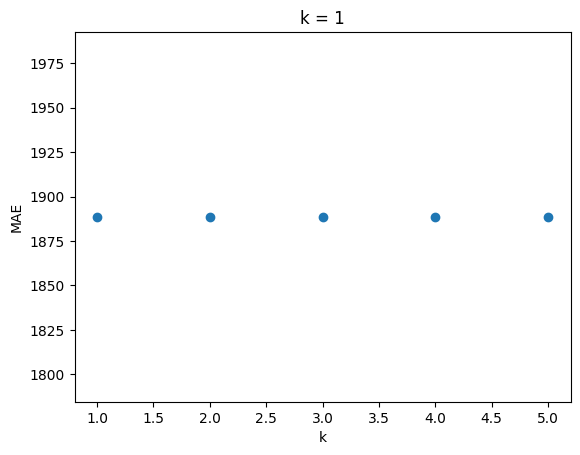

In [ ]:
range_k = np.arange(1, 6, 1)

error = [None] * len(range_k)

for idx, k in enumerate(range_k): 
    imputer = KNNImputer(n_neighbors=k) # initialize imputer 
    X_train_I = imputer.fit_transform(X_missing) # fit and transform training set 
    X_train_I = pd.DataFrame(X_train_I, columns=X_missing.columns, index=X_missing.index)

    replaced_rows = X_train_I.iloc[rand_idx] # imputed 
    true_vals = X_train_copy.iloc[rand_idx] # true values 

    error[idx] = np.nanmean(np.abs(replaced_rows - true_vals).mean(axis=1))

print(error)

min_error_idx = np.argmin(error)
best_k = range_k[min_error_idx]

plt.scatter(x=range_k, y=error)
plt.xlabel('k')
plt.ylabel('MAE')
plt.title(f'k = {best_k}')
plt.show()


# well that was not helpful...

In [ ]:
# now, fill in for actual dataset 
knn_imputer = KNNImputer(n_neighbors=1) # use k from best fit above 
X_train_I = knn_imputer.fit_transform(X_train)
X_test_I = knn_imputer.transform(X_test)

In [ ]:
# final dataset
X_train = pd.DataFrame(X_train_I, columns=X_train.columns)
X_test = pd.DataFrame(X_test_I, columns=X_test.columns)

# confirm all values are now non-null 
print(f"Contains missing values: {X_train_I.isna().any().any()}")
print(f"Contains missing values: {X_test_I.isna().any().any()}")

Contains missing values: False
Contains missing values: False


# Exploratory Data Analysis

Before we can begin our data analysis, we must first split our data into train vs test sets, as well as scale our data. 